In [1]:
import sys
lib_path = [r'C:\Users\ikahbasi\OneDrive\Applications\GitHub\SeisRoutine',
            r'C:\Users\ikahb\OneDrive\Applications\GitHub\SeisRoutine',
            '/home/ikahbasi/Works/SeisRoutine']
for path in lib_path:
    sys.path.append(path)
##########################################################################
import SeisRoutine.catalog as src
import SeisRoutine.waveform as srw
import SeisRoutine.config as srconf
import SeisRoutine.statistics as srs
import SeisRoutine.plot as srp
##########################################################################
import myfuncs as mf

In [2]:
import seisbench.generate as sbg
import seisbench.models as sbm
import torch
from tqdm import tqdm
from scipy import signal
import os
import seisbench.data as sbd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
import pandas as pd
import logging
from obspy import UTCDateTime as utc


# Classes and Functions

In [3]:
init_cfg = srconf.load_config('0-init-cfg.yml')
cfg_path = os.path.join(init_cfg.target_config_filepath,
                        init_cfg.target_config_filename)
cfg = srconf.load_config(cfg_path)

In [4]:
srconf.configure_logging(level=cfg.log.level,
                         log_format=cfg.log.format,
                         mode=cfg.log.mode, colored_console=True,
                         filepath=cfg.dataset.path,
                         filename_prefix=cfg.log.filename_prefix,
                         filename=cfg.log.filename)

Logging Starts in:
/media/ikahbasi/Local Disk ikahbasi 4T1/DataSets-Local/AutoLabeling_on_Merged_datasets_2026-01-06_13-20-26.log


In [5]:
def filter_min_residual(row, key):
    el = row[key]
    if isinstance(el, np.ndarray):
        if all(np.isnan(el)):
            output = np.nan
        else:
            output = el[np.argmin(np.abs(el))]
    else:
        if np.isnan(el):
            output = np.nan
        if isinstance(el, (int, float, complex)):
            output = el
        else:
            print(el, type(el))
    return output

In [7]:
# path = '/media/ikahbasi/Local Disk ikahbasi 4T1/DataSets-Local/Merged_All_DataSets_2025-07-10 (Ahar-Ilam-Kaki-Qeshm)/metadata-with-AutoPicks-2026.01.06-07.46.34.pkl'
path = r'F:\DataSets-Local\Merged_All_DataSets_2025-07-10 (Ahar-Ilam-Kaki-Qeshm)/metadata-with-AutoPicks-2026.01.06-07.46.34.pkl'

metadata = pd.read_pickle(path)

In [8]:
metadata_res = metadata.copy()
metadata[[key for key in metadata.keys() if key.startswith('trace_S')]]

metadata_res['trace_P_PhaseNet_original-AutoPik'] -= metadata_res['trace_Pg_arrival_sample']
metadata_res['trace_P_EQTransformer_original-AutoPik'] -= metadata_res['trace_Pg_arrival_sample']

metadata_res['trace_S_PhaseNet_original-AutoPik'] -= metadata_res['trace_Sg_arrival_sample']
metadata_res['trace_S_EQTransformer_original-AutoPik'] -= metadata_res['trace_Sg_arrival_sample']

keys = [key for key in metadata.keys() if key.endswith('-AutoPik')]
for key in keys:
    metadata_res[key] = metadata_res.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)

In [9]:
# diff['id'] = diff.index
# diff.reset_index(drop=True)
# keys = diff.keys().tolist()
# keys.remove('catalog_picktime')
# keys.remove('catalog_pickdist')
# keys.remove('id')

# # diff_filtered = diff[diff['catalog_picktime'].notna()]
# for phase in ['_P', '_S']:
#     diff_filtered = diff[diff['id'].str.endswith(phase)].copy()
#     print(phase)
#     # print(filtered)
#     for key in keys:
#         diff_filtered[key] = diff_filtered.apply(lambda x: filter_min_residual(row=x, key=key), axis=1)
#         # diff_filtered2 = diff_filtered.explode(key)
#         diff_filtered2 = diff_filtered[diff_filtered[key].notna()]

#         # diff_filtered2[key, 'catalog_pickdist']
#         arr_error = diff_filtered2[key].values
#         arr_dist = diff_filtered2['catalog_pickdist'].values
#         msk = np.abs(arr_error) <= 10
#         arr_error = arr_error[msk].tolist()
#         arr_dist = arr_dist[msk].tolist()
#         #
#         # arr_dist = filtered['catalog_pickdist'][msk].values
#         srp.histogram(arr_error,
#                       orientation='vertical',
#                       figsize=(6, 4), title=f'{key}  {phase}', around_zero=False, step=0.5,
#                       xlim=[-5, 5],
#                       xlabel='Residual [$t_M - t_C$]', ylabel='Count',
#                       save=True, savefile=f'{key}{phase}_hist.png')
#         srp.density_hist(x=arr_dist, y=arr_error,
#                          xstep=5, ystep=0.25,
#                          ylim=[-4, 4],
#                          figsize=(10, 4), title=f'{key}  {phase}',
#                          xlabel='Distance [km]', ylabel='Residual [$t_M - t_C$]',
#                          save=True, savefile=f'{key}{phase}_dist.png')

In [10]:
metadata_res.shape

(81014, 108)

62996


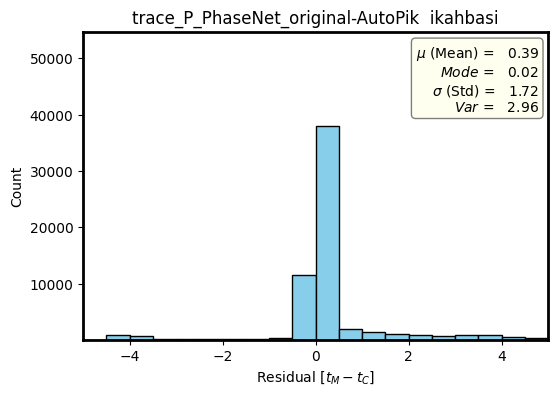

43545


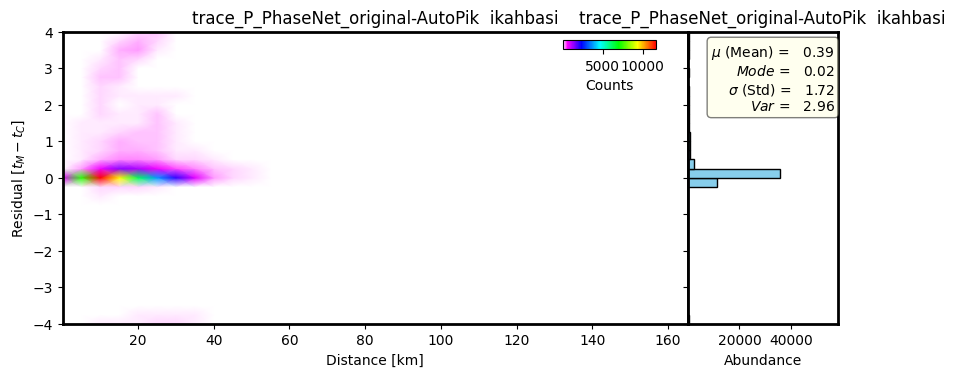

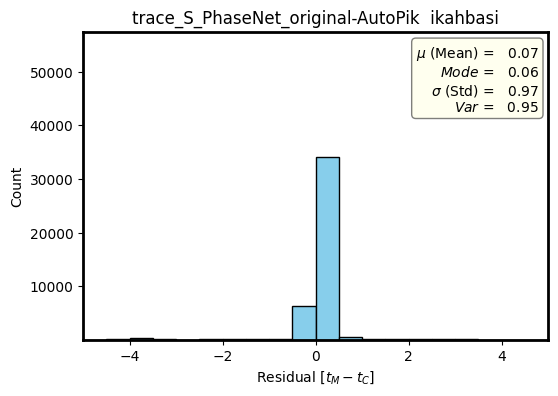

52228


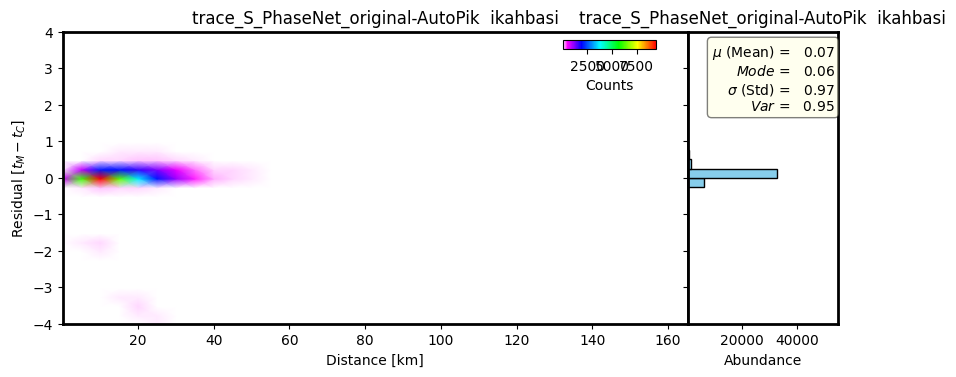

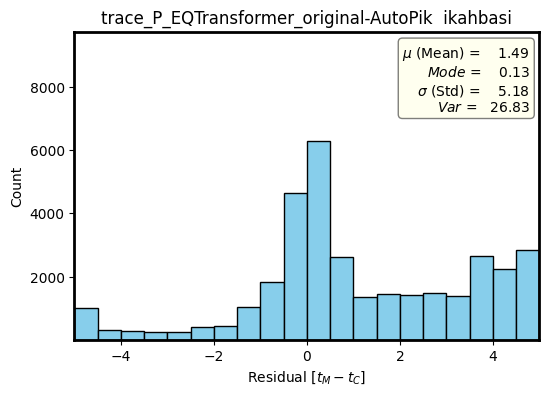

17090


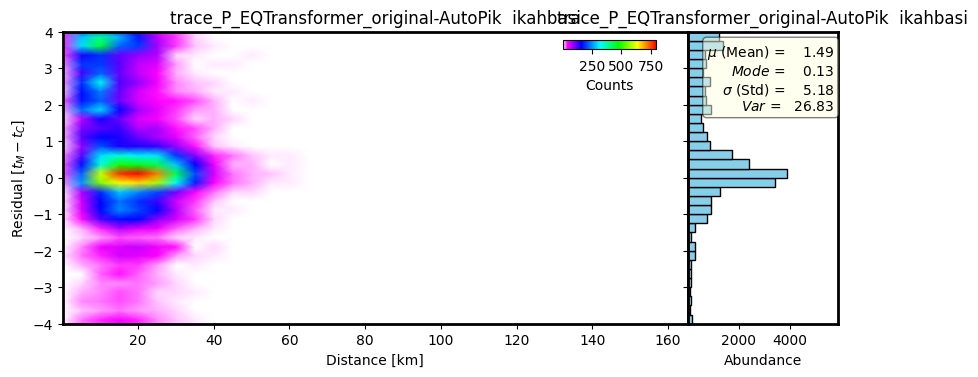

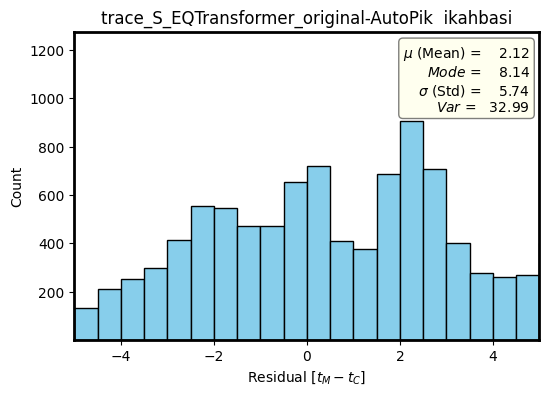

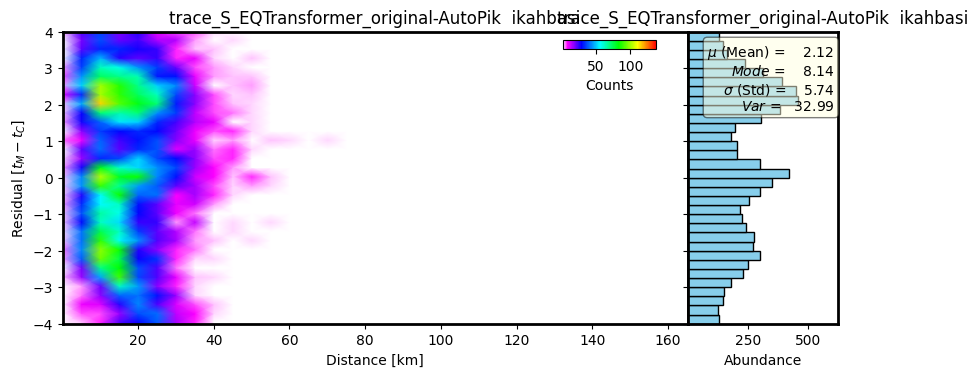

In [11]:
sps = 100
phase = 'ikahbasi'
for key in keys:
    msk1 = metadata_res[key].notna()
    msk2 = (metadata_res[key]/sps) <= 10
    metadata_res_selected = metadata_res[msk1 & msk2]
    arr_dist = metadata_res_selected['path_ep_distance_km'].values
    arr_error = metadata_res_selected[key].values /sps
    print(arr_error.size)
    srp.histogram(arr_error,
                orientation='vertical',
                figsize=(6, 4), title=f'{key}  {phase}', around_zero=False, step=0.5,
                xlim=[-5, 5],
                xlabel='Residual [$t_M - t_C$]', ylabel='Count',
                save=False, savefile=f'{key}{phase}_hist.png')
    srp.density_hist(x=arr_dist, y=arr_error,
                    xstep=5, ystep=0.25,
                    ylim=[-4, 4],
                    figsize=(10, 4), title=f'{key}  {phase}',
                    xlabel='Distance [km]', ylabel='Residual [$t_M - t_C$]',
                    save=False, savefile=f'{key}{phase}_dist.png')

In [52]:
# pred = dl_picker(data_X)
# pred = pred.detach()
# for index, p in enumerate(pred):
#     plt.plot(p.cpu().T, label=index)
# plt.legend()

In [53]:
# for index, p in enumerate(pred):
#     plt.plot(p.cpu().T, label=index)
# plt.legend()